In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [86]:
df_ind = df[df['job_country'] == 'India'].copy()
df_ind = df_ind.dropna(subset=['job_skills'])
df_ind['job_posted_month_no'] = df_ind['job_posted_date'].dt.month

In [87]:
df_ind_skill = df_ind.explode('job_skills')
df_ind_skill_pivot = df_ind_skill.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_ind_skill_pivot.loc['Total'] = df_ind_skill_pivot.sum()
df_ind_skill_pivot = df_ind_skill_pivot[df_ind_skill_pivot.loc['Total'].sort_values(ascending=False).index]
df_ind_skill_pivot = df_ind_skill_pivot.drop('Total')


In [88]:
df_month_count = df_ind.groupby('job_posted_month_no').size()


In [89]:
df_ind_skill_pivot = df_ind_skill_pivot.div(df_month_count/100, axis=0)

In [90]:
df_ind_skill_pivot = df_ind_skill_pivot.reset_index()
df_ind_skill_pivot['job_posted_month'] = df_ind_skill_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_ind_skill_pivot = df_ind_skill_pivot.set_index('job_posted_month')
df_ind_skill_pivot = df_ind_skill_pivot.drop(columns='job_posted_month_no')
df_ind_skill_pivot = df_ind_skill_pivot.iloc[:, :5]
df_ind_skill_pivot

job_skills,python,sql,aws,spark,azure
job_posted_month,,,,,
Jan,63.929501,64.710595,28.179451,28.620068,27.077909
Feb,62.976457,63.733184,28.699552,30.128924,25.756726
Mar,65.074627,65.237449,29.389417,29.742198,26.132972
Apr,62.884030,65.485746,29.725989,30.251868,25.961805
May,66.700508,66.023689,32.622673,31.167513,27.851100
Jun,68.178244,65.923984,31.454784,31.900393,27.758847
Jul,65.665584,66.531385,30.059524,28.246753,28.679654
Aug,64.215294,64.908074,30.242473,29.070077,26.005862
Sep,63.706140,63.651316,28.316886,25.000000,26.754386


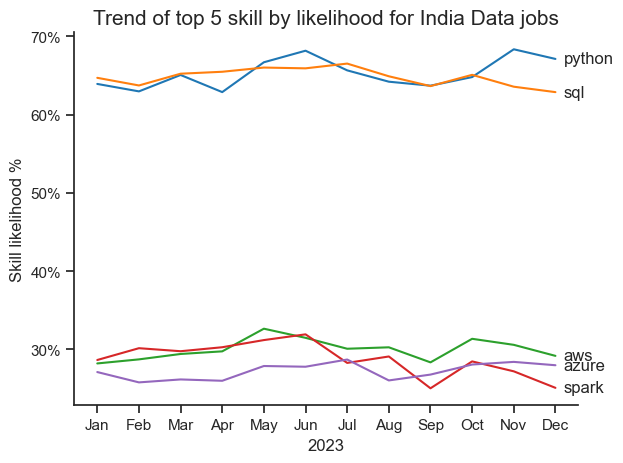

In [95]:
sns.set_theme(style='ticks')
sns.lineplot(data=df_ind_skill_pivot, dashes=None, legend=False, palette='tab10')
sns.despine() 
plt.xlabel('2023')
plt.ylabel('Skill likelihood %')
plt.title('Trend of top 5 skill by likelihood for India Data jobs', fontsize=15)

for i in range(5):
    plt.text(11.2, df_ind_skill_pivot.iloc[-1,i], df_ind_skill_pivot.columns[i], va='center')

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()